In [ ]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Path to the extracted dataset folder
# Based on kernel state, root folder is 'dataset/Bottle Images'
base_dir = 'dataset/Bottle Images'

# Use ImageDataGenerator to split train/test (validation_split=0.3)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 17500 images belonging to 5 classes.
Found 7500 images belonging to 5 classes.


In [11]:
# Build MobileNet model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Corrected to categorical_crossentropy
model.compile(optimizer='adam', loss='categorical_crossentropy' if train_generator.num_classes > 2 else 'binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting model training...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)

Starting model training...
Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1343s 2s/step - accuracy: 0.8574 - loss: 0.3960 - val_accuracy: 0.9233 - val_loss: 0.2069
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1347s 2s/step - accuracy: 0.9063 - loss: 0.2517 - val_accuracy: 0.9184 - val_loss: 0.2217
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1315s 2s/step - accuracy: 0.9171 - loss: 0.2221 - val_accuracy: 0.9371 - val_loss: 0.1707
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1318s 2s/step - accuracy: 0.9235 - loss: 0.1995 - val_accuracy: 0.9417 - val_loss: 0.1532
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1360s 2s/step - accuracy: 0.9309 - loss: 0.1906 - val_accuracy: 0.9436 - val_loss: 0.1515
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1327s 2s/step - accuracy: 0.9323 - loss: 0.1812 - val_accuracy: 0.9439 - val_loss: 0.1453
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1314s 2s/step - accuracy: 0.9355 - loss: 0.1732 - val_accuracy: 0.9385 - val_loss: 0.1682
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 1333s 2s/step - accurac

In [12]:
# Calculate and display post-training results
loss, accuracy = model.evaluate(validation_generator)
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.9587 - loss: 0.1192
Test accuracy: 95.87%
Test loss: 0.1192


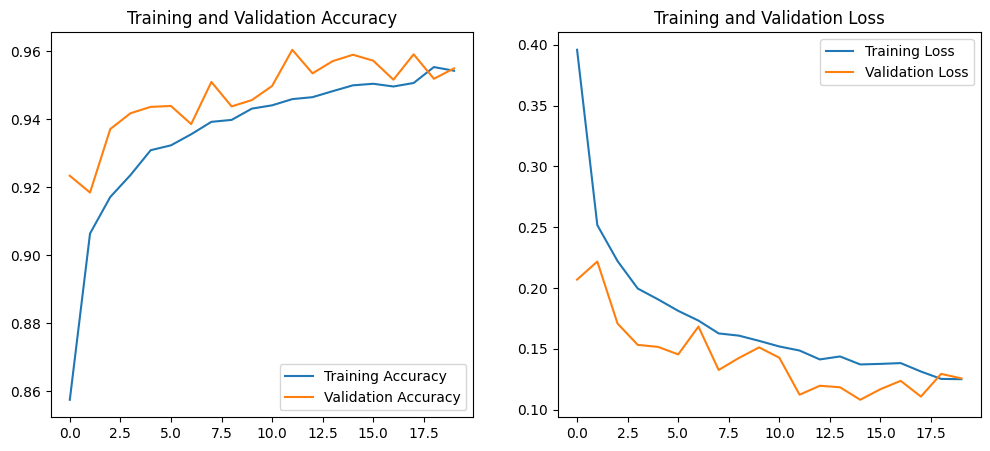

In [13]:
# Display training charts
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()